In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)


In [3]:
DATA_PATH = "Task_3_and_4_Loan_Data.csv"
df = pd.read_csv(DATA_PATH)
print(df.shape)

(10000, 8)


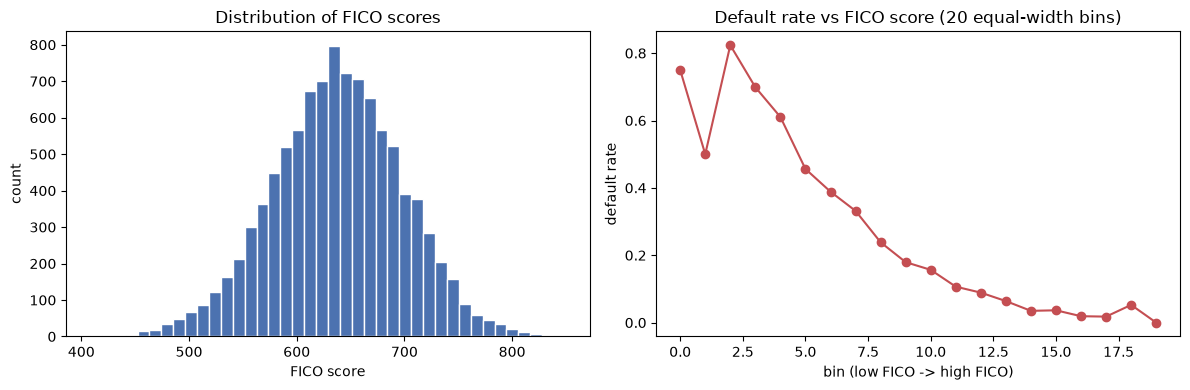

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['fico_score'], bins=40, color='#4C72B0', edgecolor='white')
axes[0].set_title('Distribution of FICO scores')
axes[0].set_xlabel('FICO score')
axes[0].set_ylabel('count')

rough = df.groupby(pd.cut(df['fico_score'], bins=20))['default'].mean()
axes[1].plot(range(len(rough)), rough.values, marker='o', color='#C44E52')
axes[1].set_title('Default rate vs FICO score (20 equal-width bins)')
axes[1].set_xlabel('bin (low FICO -> high FICO)')
axes[1].set_ylabel('default rate')

plt.tight_layout()
plt.show()


In [5]:
def aggregate_by_fico(data, fico_col='fico_score', default_col='default'):
    grouped = (
        data.groupby(fico_col)
            .agg(count=(default_col, 'size'), defaults=(default_col, 'sum'))
            .reset_index()
            .rename(columns={fico_col: 'fico_score'})
            .sort_values('fico_score')
            .reset_index(drop=True)
    )
    return grouped

grouped = aggregate_by_fico(df)
print(f"{len(grouped)} unique FICO scores, {grouped['count'].sum()} total records")
grouped.head()


374 unique FICO scores, 10000 total records


,fico_score,count,defaults
0,408,1,0
1,409,1,1
2,418,1,1
3,425,1,1
4,438,1,1


In [6]:
def generate_boundaries(grouped, num_buckets, method='loglikelihood'):
    values  = grouped['fico_score'].values.astype(float)
    counts  = grouped['count'].values.astype(float)
    defaults = grouped['defaults'].values.astype(float)
    N = len(values)

    if not (1 <= num_buckets <= N):
        raise ValueError(f"num_buckets must be between 1 and {N} (unique scores available)")

    # prefix sums, so any bucket's cost is O(1) to compute
    cum_n  = np.concatenate([[0], np.cumsum(counts)])
    cum_x  = np.concatenate([[0], np.cumsum(counts * values)])
    cum_x2 = np.concatenate([[0], np.cumsum(counts * values ** 2)])
    cum_k  = np.concatenate([[0], np.cumsum(defaults)])

    def sse(i, j):
        n = cum_n[j] - cum_n[i]
        if n == 0:
            return 0.0
        sx  = cum_x[j]  - cum_x[i]
        sx2 = cum_x2[j] - cum_x2[i]
        return sx2 - (sx ** 2) / n

    def neg_loglik(i, j):
        n = cum_n[j] - cum_n[i]
        k = cum_k[j] - cum_k[i]
        if n == 0 or k == 0 or k == n:
            return 0.0  # by convention 0*log(0) = 0 -> homogeneous bucket costs nothing extra
        p = k / n
        return -(k * np.log(p) + (n - k) * np.log(1 - p))

    if method == 'mse':
        cost_fn = sse
    elif method == 'loglikelihood':
        cost_fn = neg_loglik  # minimize the negative == maximize the log-likelihood
    else:
        raise ValueError("method must be 'mse' or 'loglikelihood'")

    INF = float('inf')
    dp    = np.full((num_buckets + 1, N + 1), INF)
    split = np.zeros((num_buckets + 1, N + 1), dtype=int)
    dp[0][0] = 0.0

    for k in range(1, num_buckets + 1):
        for j in range(k, N + 1):
            best, best_i = INF, -1
            for i in range(k - 1, j):
                if dp[k - 1][i] == INF:
                    continue
                cost = dp[k - 1][i] + cost_fn(i, j)
                if cost < best:
                    best, best_i = cost, i
            dp[k][j] = best
            split[k][j] = best_i

    # backtrack to recover the bucket edges
    idxs, j, k = [], N, num_buckets
    while k > 0:
        i = split[k][j]
        idxs.append(i)
        j = i
        k -= 1
    idxs.append(0)
    edges_idx = sorted(set(idxs)) + [N]

    boundary_scores = [int(values[e]) if e < N else int(values[-1]) for e in edges_idx]
    total_cost = dp[num_buckets][N]
    return boundary_scores, edges_idx, total_cost


In [7]:
NUM_BUCKETS = 5

boundaries_mse, edges_mse, cost_mse = generate_boundaries(grouped, NUM_BUCKETS, method='mse')
boundaries_ll,  edges_ll,  cost_ll  = generate_boundaries(grouped, NUM_BUCKETS, method='loglikelihood')

print("MSE boundaries          :", boundaries_mse, " (total SSE = %.1f)" % cost_mse)
print("Log-likelihood boundaries:", boundaries_ll,  " (total log-lik = %.1f)" % -cost_ll)


MSE boundaries          : [408, 553, 608, 655, 707, 850]  (total SSE = 2976841.8)
Log-likelihood boundaries: [408, 521, 581, 641, 697, 850]  (total log-lik = -4255.4)


In [8]:
def bucket_stats(grouped, edges_idx):
    values = grouped['fico_score'].values
    cum_n = np.concatenate([[0], np.cumsum(grouped['count'].values)])
    cum_k = np.concatenate([[0], np.cumsum(grouped['defaults'].values)])

    rows = []
    for b in range(len(edges_idx) - 1):
        i, j = edges_idx[b], edges_idx[b + 1]
        n = cum_n[j] - cum_n[i]
        k = cum_k[j] - cum_k[i]
        rows.append({
            'bucket': b,
            'fico_min': int(values[i]),
            'fico_max': int(values[j - 1]),
            'n_records': int(n),
            'n_defaults': int(k),
            'default_rate': round(k / n, 4) if n > 0 else np.nan,
        })
    return pd.DataFrame(rows)

print("MSE-optimized buckets:")
display(bucket_stats(grouped, edges_mse))

print("\nLog-likelihood-optimized buckets:")
display(bucket_stats(grouped, edges_ll))


MSE-optimized buckets:


,bucket,fico_min,fico_max,n_records,n_defaults,default_rate
0,0,408,552,797,428,0.5370
1,1,553,607,2240,635,0.2835
2,2,608,654,3036,488,0.1607
3,3,655,706,2634,242,0.0919
4,4,707,850,1293,58,0.0449



Log-likelihood-optimized buckets:


,bucket,fico_min,fico_max,n_records,n_defaults,default_rate
0,0,408,520,301,199,0.6611
1,1,521,580,1407,536,0.3810
2,2,581,640,3438,703,0.2045
3,3,641,696,3197,336,0.1051
4,4,697,850,1657,77,0.0465


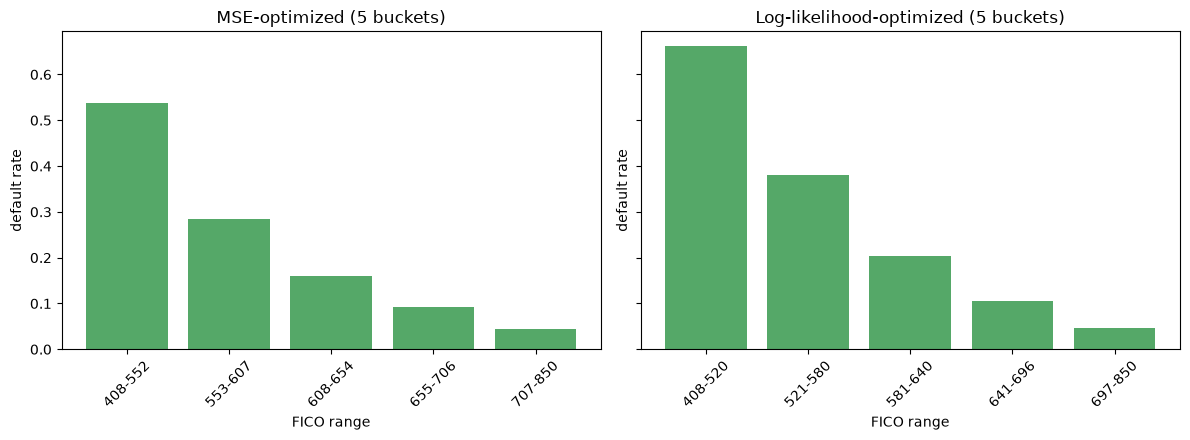

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for ax, edges, title in [
    (axes[0], edges_mse, f'MSE-optimized ({NUM_BUCKETS} buckets)'),
    (axes[1], edges_ll,  f'Log-likelihood-optimized ({NUM_BUCKETS} buckets)'),
]:
    stats = bucket_stats(grouped, edges)
    labels = [f"{r.fico_min}-{r.fico_max}" for r in stats.itertuples()]
    ax.bar(labels, stats['default_rate'], color='#55A868')
    ax.set_title(title)
    ax.set_xlabel('FICO range')
    ax.set_ylabel('default rate')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [10]:
class FICORatingMap:
    """Maps a raw FICO score to a discrete rating. Lower rating = better credit score."""

    def __init__(self, boundaries):
        self.boundaries = sorted(boundaries)
        self.num_buckets = len(self.boundaries) - 1
        if self.num_buckets < 1:
            raise ValueError("Need at least 2 boundary points to define 1 bucket")

    def get_rating(self, fico_score):
        idx = np.searchsorted(self.boundaries, fico_score, side='right') - 1
        idx = int(np.clip(idx, 0, self.num_buckets - 1))
        return self.num_buckets - idx  # highest-FICO bucket -> rating 1

    def get_ratings(self, fico_scores):
        return np.array([self.get_rating(s) for s in np.atleast_1d(fico_scores)])

    def bucket_range(self, rating):
        idx = self.num_buckets - rating
        return self.boundaries[idx], self.boundaries[idx + 1]

    def summary(self):
        rows = [
            {'rating': r, 'fico_min': self.bucket_range(r)[0], 'fico_max': self.bucket_range(r)[1]}
            for r in range(1, self.num_buckets + 1)
        ]
        return pd.DataFrame(rows).sort_values('rating').reset_index(drop=True)

    def __repr__(self):
        return f"FICORatingMap(num_buckets={self.num_buckets}, boundaries={self.boundaries})"


rating_map = FICORatingMap(boundaries_ll)
print(rating_map)
rating_map.summary()


FICORatingMap(num_buckets=5, boundaries=[408, 521, 581, 641, 697, 850])


,rating,fico_min,fico_max
0,1,697,850
1,2,641,697
2,3,581,641
3,4,521,581
4,5,408,521


In [11]:
for score in [420, 560, 610, 660, 700, 780, 850]:
    print(f"FICO {score:>3} -> rating {rating_map.get_rating(score)}")


FICO 420 -> rating 5
FICO 560 -> rating 4
FICO 610 -> rating 3
FICO 660 -> rating 2
FICO 700 -> rating 1
FICO 780 -> rating 1
FICO 850 -> rating 1


In [12]:
def build_rating_map(data, num_buckets, method='loglikelihood',
                      fico_col='fico_score', default_col='default'):
    grouped = aggregate_by_fico(data, fico_col=fico_col, default_col=default_col)
    boundaries, edges_idx, cost = generate_boundaries(grouped, num_buckets, method=method)
    rating_map = FICORatingMap(boundaries)
    stats = bucket_stats(grouped, edges_idx)
    return rating_map, stats, cost


# Example: an model with 10 input labels needs 10 buckets
rating_map_10, stats_10, cost_10 = build_rating_map(df, num_buckets=10, method='loglikelihood')
stats_10


,bucket,fico_min,fico_max,n_records,n_defaults,default_rate
0,0,408,520,301,199,0.6611
1,1,521,552,496,229,0.4617
2,2,553,580,911,307,0.3370
3,3,581,611,1561,381,0.2441
4,4,612,649,2465,402,0.1631
5,5,650,696,2609,256,0.0981
6,6,697,732,1104,64,0.0580
7,7,733,752,303,5,0.0165
8,8,753,753,8,3,0.3750
9,9,754,850,242,5,0.0207


In [13]:
new_applicants = pd.DataFrame({
    'customer_id': [90001, 90002, 90003, 90004],
    'fico_score':  [455, 588, 671, 809],
})
new_applicants['rating'] = rating_map_10.get_ratings(new_applicants['fico_score'])
new_applicants


,customer_id,fico_score,rating
0,90001,455,10
1,90002,588,7
2,90003,671,5
3,90004,809,1
